In [1]:
import torch 
import torch.nn as nn 
import matplotlib.pyplot as plt 
import numpy as np 

In [2]:
# from model import NeuralNetwork
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.l1 = nn.Linear(784, 100)
        self.l2 = nn.Linear(100,50)
        self.l3 = nn.Linear(50,10)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)
    def forward(self,x):
        x = self.l1(x)
        h_pre_l1 = x.clone()
        x = self.relu(x)
        h_post_l1 = x.clone()
        x = self.l2(x)
        h_pre_l2 = x.clone()
        x = self.relu(x)
        h_post_l2 = x.clone()
        x = self.l3(x)

        return x, h_pre_l1, h_post_l1, h_pre_l2, h_post_l2

In [3]:
model = NeuralNetwork()

In [4]:
PATH = './weights/model.pt'
model.load_state_dict(torch.load(PATH))

<All keys matched successfully>

In [5]:
# # layer_1 = model.l1 
# # layer_1.type()
# # type(layer_1.weight)
# print(torch.linalg.matrix_rank(layer_1.weight))
layers = []
model_layers = [model.l1, model.l2, model.l3]
for layer in model_layers:
    layers.append(layer.weight.detach().cpu().numpy())
print(len(layers))

3


In [6]:
def plot_singular_values(numpy_weights):
    i = 0
    for weight in numpy_weights:
        i += 1
        U, S, Vt = np.linalg.svd(weight)

        plt.figure()
        plt.plot(S)
        plt.title(f"Singular values – Layer {i}")
        plt.xlabel("Index")
        plt.ylabel("Magnitude")
        plt.show()
def plot_weight_distributions(weights, bins=50):
    i = 0
    for weight in weights:
        i+=1
        flat = weight.flatten()
        plt.figure()
        plt.hist(flat, bins=bins, density=True)
        plt.title(f"Weight distribution – Layer {i}")
        plt.xlabel("Weight value")
        plt.ylabel("Density")
        plt.show()
def plot_weight_heatmap(weights):
    i = 0
    for weight in weights: 
        i+=1
        plt.figure()
        plt.imshow(weight)
        plt.title(f"Weight distribution - Layer {i}")
        plt.ylabel("Heat Map")
        plt.show()
def square_matrix(layer):
    M = layer @ layer.T 
    return M

In [7]:
square_layers = [square_matrix(layer) for layer in layers]

In [8]:
U, S1, Vt = np.linalg.svd(layers[0], full_matrices=False)
U, S2, Vt = np.linalg.svd(layers[1])
U, S3, Vt = np.linalg.svd(layers[2])
# print(np.sum(np.log(S)))
print(np.prod(S1))
print(np.prod(S2))
print(np.prod(S3))

4.773901e-24
2.141304e-14
0.28381371


In [9]:
print("max L1:", S1.max())
print("min l2 :", S1.min())
print("cond l3:", S1.max()/S1.min())

print("max L1:", S2.max())
print("min l2 :", S2.min())
print("cond l3:", S2.max()/S2.min())

print("max L1:", S3.max())
print("min l2 :", S3.min())
print("cond l3:", S3.max()/S3.min())


max L1: 1.2288592
min l2 : 0.38291165
cond l3: 3.20925
max L1: 1.2886193
min l2 : 0.17877954
cond l3: 7.2078676
max L1: 1.2109537
min l2 : 0.5982263
cond l3: 2.0242403


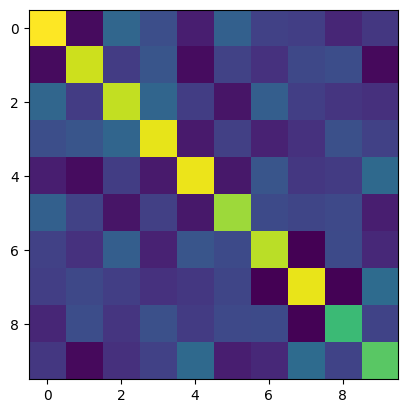

In [10]:
Q = model.l3.weight.detach().cpu().numpy()
SQUARE = Q @ Q.T
plt.imshow(SQUARE)
plt.show()

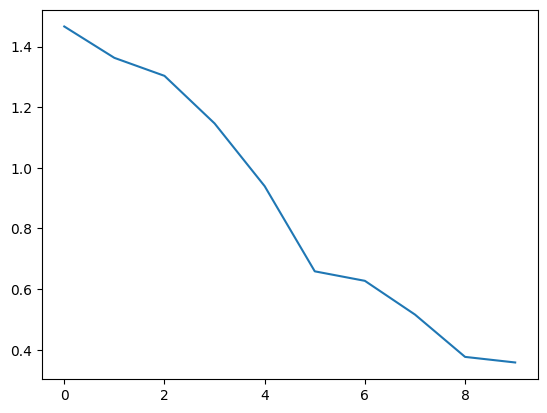

In [11]:
U, S, Vt = np.linalg.svd(SQUARE)
plt.plot(S)


In [12]:
import numpy as np 
S = np.linalg.eigvals(SQUARE @ SQUARE.T)  # these are σ²

# S = torch.from_numpy(S)
effective_rank = (np.sum(S)**2)/(np.sum(S**2))
print(effective_rank)

6.170303


In [13]:
# import matplotlib.pyplot as plt
# W = layers[0]
# # for i in range(10):
# #     img = W[i].reshape(28, 28)
# #     img = img / np.max(np.abs(img))  # normalize
# #     plt.imshow(img, cmap='gray', vmin=-1, vmax=1)
# #     plt.axis('off')
# #     plt.show()
# # Suppose last layer weight matrix is W_last (10 x H)
# W_last = model.l3.weight.detach().cpu().numpy()

# # Find which neurons strongly contribute to class 3
# class_idx = 3
# top_neurons = np.argsort(np.abs(W_last[class_idx]))[-5:]

# for i in top_neurons:
#     img = W[i].reshape(28,28)
#     img = img / np.max(np.abs(img))
#     plt.imshow(img, cmap='gray', vmin=-1, vmax=1)
#     plt.axis('off')
#     plt.show()


In [14]:
#checking weights/activations 
from torchvision import datasets, transforms 
from torch.utils.data import DataLoader
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
test_dataset = datasets.MNIST(root='Experiments/Exp-1/dataset', train=False, transform=transform, download=False)

In [15]:
model.eval()
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [16]:
single_batch = iter(test_loader)
inputs, labels = next(single_batch)
inputs = inputs.view(inputs.size(0), 28*28)   
outputs,h_pre_l1, h_post_l1, h_pre_l2, h_post_l2 = model(inputs[0])

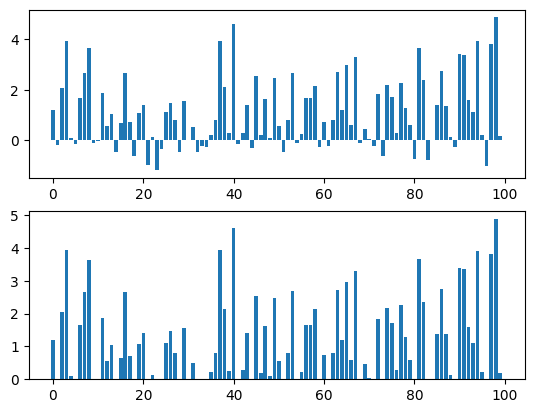

In [27]:
plt.subplot(2,1,1)
plt.bar(range(len(h_pre_l1)), h_pre_l1.detach().numpy())
plt.subplot(2,1,2)
plt.bar(range(len(h_post_l1)), h_post_l1.detach().numpy())
plt.show()

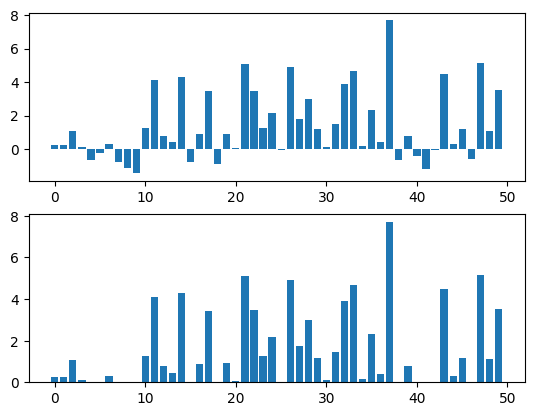

In [28]:
plt.subplot(2,1,1)
plt.bar(range(len(h_pre_l2)), h_pre_l2.detach().numpy())
plt.subplot(2,1,2)
plt.bar(range(len(h_post_l2)), h_post_l2.detach().numpy())
plt.show()